# Project Introduction

This project serves to improve decision-making to address the growing national concern over the loss of control that patients have near the end of their lives and to reduce the frequency of a mechanical, painful, and prolonged process of dying. An extensive Initial and Exploratory data analysis will identify, patterns, trends and findings needed to facilitate this decision making process. It will ultimately be used to develop a model to estimate the survival chances over a 180 day period to chronically hospitalized patients. Good predictive interventions reduce several impacts of dying drastically, prolonging the patients' dying process.

# Problem Context

The growing national concern over patients' loss of control near the end of life is an important problem. Despite this concern, which has been known since the 1980s, a noticeable absence of decision-making interventions to prolong patient death processes has been observed. To develop a prognostic model to estimate survival chances of these patients, the dataset gathered is rife with missing values. Some default values have been identified to handle missing values. However, an extensive IDA must be performed to improve the quality of the dataset. This is to improve the predictive ability of a progostic model that will rely on its quality. The predictions made will enable earlier decisions and planning to reduce the frequency of a mechanical, painful, and prolonged dying process.

# Project Objectives

1. Perform an extensive initial data analysis to preprocess dataset for model training
2. Perform a thorough exploratory data analysis of the dataset by analyzing and visualizing to derive patterns and key findings

# Dataset

This dataset comprises 9105 individual critically ill patients across 5 United States medical centers, accessioned throughout 1989-1991 and 1992-1994. Each row concerns hospitalized patient records who met the inclusion and exclusion criteria for nine disease categories: acute respiratory failure, chronic obstructive pulmonary disease, congestive heart failure, liver disease, coma, colon cancer, lung cancer, multiple organ system failure with malignancy, and multiple organ system failure with sepsis. Data sources are medical records, personal interviews, and the National Death Index (NDI). For each patient administrative records data, clinical data and survey data were collected. The dataset can be found on the UC Irvine Machine Learning Repository website.

# Research Questions

1. What is the distribution of PRG2M and PRG6M? What do their average values indicate about the short and long term survival rates of patients?
2. What does the age distribution of patients say about age related patterns in the dataset?
3. What findings are discoverd in exploring the distribution of patient hospital deaths?
4. How does patient sex impact survival rates?
5. What does the distribution of disease groups and classes patients fall under reveal?
6. What is the distribution of Comorbidities in the dataset?
7. Which age category(ies) are associated with higher hospital deaths?
8. What does the relationship between the number of patient comorbidities and its impact on the number of hospital mortality rates reveal?
9. How do the ages of the patients relate to their two and six month survival outcomes?
10. Which disease classes illustrate the short and long term chances of survival of patients(two and six months respectively)?
11. How does a patient's physiology score influence his/her chances of survival?
12. How does a patient's race impact physician’s 2 and 6 month survival estimates?
13. How do short and long term survival rates (by model or physician) impact gender?
14. Which physiological measure(s) correlates with survival at 2 and 6 months respectively?
15. What combination of physiological markers best impacts survival chances in two and six months?

Research Questions

1. How does race, age and gender impact mortality rates?
2. How does acid base impact patient mortality?
3. Which physiological measure(s) correlates with survival at 2 and 6 months respectively?
4. What is the distribution of PRG2M and PRG6M? What do their average values indicate about the short and long term survival rates of patients?
5. What combination of physiological markers best impacts survival chances in two and six months?
6. What findings are discoverd in exploring the distribution of patient hospital deaths?
7. Do the ages of the patients relate to their two and six month survival outcomes?
8. What does the distribution of disease groups and classes patients fall under reveal?

In [419]:
import statistics as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

In [420]:
# Upload dataset
df1=pd.read_csv('support2-1.csv')
df1

,ID,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.000000
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.000000
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.000000
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.000000
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,9101,66.07300,0,male,0,23,350,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.099854,131.0,7.459961,188.0,21.0,NaN,NaN,0.0,NaN,0.000000
9101,9102,55.15399,0,female,0,29,347,Coma,Coma,1,...,5.899414,135.0,7.289062,190.0,49.0,0.0,NaN,0.0,NaN,0.000000
9102,9103,70.38196,0,male,0,8,346,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,2.699707,139.0,7.379883,189.0,60.0,3900.0,NaN,NaN,NaN,2.525391
9103,9104,47.01999,1,male,1,7,7,MOSF w/Malig,ARF/MOSF,1,...,3.500000,135.0,7.469727,246.0,55.0,NaN,NaN,0.0,<2 mo. follow-up,0.000000


In [421]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzclass   9105 non-null   object 
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   object 
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   object 
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   floa

## Initial Data Analysis (IDA)

### Standardize columns

In [422]:
df1.columns=df1.columns.str.upper()
df1

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,CREA,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.000000
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.000000
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.000000
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.000000
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,9101,66.07300,0,male,0,23,350,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.099854,131.0,7.459961,188.0,21.0,NaN,NaN,0.0,NaN,0.000000
9101,9102,55.15399,0,female,0,29,347,Coma,Coma,1,...,5.899414,135.0,7.289062,190.0,49.0,0.0,NaN,0.0,NaN,0.000000
9102,9103,70.38196,0,male,0,8,346,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,2.699707,139.0,7.379883,189.0,60.0,3900.0,NaN,NaN,NaN,2.525391
9103,9104,47.01999,1,male,1,7,7,MOSF w/Malig,ARF/MOSF,1,...,3.500000,135.0,7.469727,246.0,55.0,NaN,NaN,0.0,<2 mo. follow-up,0.000000


## Change Data types

In [423]:
df1['AGE']=df1['AGE'].astype(int)     # Change AGE column to integer

In [424]:
df1['D.TIME']

0       2029
1          4
2         47
3        133
4       2029
        ... 
9100     350
9101     347
9102     346
9103       7
9104     198
Name: D.TIME, Length: 9105, dtype: int64

In [425]:
df1['D.TIME']=pd.to_timedelta(df1['D.TIME'], unit='D')      # Change D.TIME to time-series(days)
df1['D.TIME']

0      2029 days
1         4 days
2        47 days
3       133 days
4      2029 days
          ...   
9100    350 days
9101    347 days
9102    346 days
9103      7 days
9104    198 days
Name: D.TIME, Length: 9105, dtype: timedelta64[ns]

In [426]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype          
---  ------    --------------  -----          
 0   ID        9105 non-null   int64          
 1   AGE       9105 non-null   int64          
 2   DEATH     9105 non-null   int64          
 3   SEX       9105 non-null   object         
 4   HOSPDEAD  9105 non-null   int64          
 5   SLOS      9105 non-null   int64          
 6   D.TIME    9105 non-null   timedelta64[ns]
 7   DZGROUP   9105 non-null   object         
 8   DZCLASS   9105 non-null   object         
 9   NUM.CO    9105 non-null   int64          
 10  EDU       7471 non-null   float64        
 11  INCOME    6123 non-null   object         
 12  SCOMA     9104 non-null   float64        
 13  CHARGES   8933 non-null   float64        
 14  TOTCST    8217 non-null   float64        
 15  TOTMCST   5630 non-null   float64        
 16  AVTISST   9023 non-null   float64        


### Missing Values

In [427]:
# locate columns with missing values

In [428]:
df1.isna().sum()         # Total Number of missing values in each column

ID             0
AGE            0
DEATH          0
SEX            0
HOSPDEAD       0
SLOS           0
D.TIME         0
DZGROUP        0
DZCLASS        0
NUM.CO         0
EDU         1634
INCOME      2982
SCOMA          1
CHARGES      172
TOTCST       888
TOTMCST     3475
AVTISST       82
RACE          42
SPS            1
APS            1
SURV2M         1
SURV6M         1
HDAY           0
DIABETES       0
DEMENTIA       0
CA             0
PRG2M       1649
PRG6M       1633
DNR           30
DNRDAY        30
MEANBP         1
WBLC         212
HRT            1
RESP           1
TEMP           1
PAFI        2325
ALB         3372
BILI        2601
CREA          67
SOD            1
PH          2284
GLUCOSE     4500
BUN         4352
URINE       4862
ADLP        5641
ADLS        2867
SFDM2       1400
ADLSC          0
dtype: int64

In [429]:
# Consider which columns to remove

In [430]:
df1['EDU'].isna().mean()*100

np.float64(17.946183415705654)

In [431]:
df1['GLUCOSE'].isna().mean()*100

np.float64(49.42339373970346)

In [432]:
df1['URINE'].isna().mean()*100

np.float64(53.39923119165294)

In [433]:
df1['ADLP'].isna().mean()*100

np.float64(61.95496979681494)

The highest count of missing values is in the ADLP column. Its percentage of missing values is not high enough to consider column removal

### Handle missing values

Due to the high percentage of missing values, there are a couple of recommended imputation values:
According to the HBiostat Repository (https://hbiostat.org/data/repo/supportdesc, Professor Frank Harrell) the following default values have been found to be useful in imputing missing baseline physiologic data:
Baseline Variable	Normal Fill-in Value
- Serum albumin (alb)	3.5
- PaO2/FiO2 ratio (pafi) 	333.3
- Bilirubin (bili)	1.01
- Creatinine (crea)	1.01
- bun	6.51
- White blood count (wblc)	9 (thousands)
- Urine output (urine)	2502
There are 159 patients surviving 2 months for whom there were no patient or surrogate interviews. These patients have missing sfdm2.

In [434]:
df1[['ALB', 'PAFI','BILI', 'CREA', 'BUN', 'WBLC', 'URINE']]

,ALB,PAFI,BILI,CREA,BUN,WBLC,URINE
0,1.799805,388.00000,0.199982,1.199951,NaN,6.000000,NaN
1,NaN,98.00000,NaN,5.500000,NaN,17.097656,NaN
2,NaN,231.65625,2.199707,2.000000,NaN,8.500000,NaN
3,NaN,NaN,NaN,0.799927,NaN,9.099609,NaN
4,NaN,173.31250,NaN,0.799927,NaN,13.500000,NaN
...,...,...,...,...,...,...,...
9100,3.699707,280.00000,0.399963,1.099854,21.0,7.399414,NaN
9101,NaN,218.50000,NaN,5.899414,49.0,NaN,0.0
9102,NaN,180.00000,0.399963,2.699707,60.0,8.398438,3900.0
9103,1.199951,428.56250,0.399963,3.500000,55.0,7.599609,NaN


In [435]:
# Replace all NaN values in ALB column with 3.5
df1['ALB']=df1['ALB'].fillna(3.5)

In [436]:
df1['ALB'].value_counts()

ALB
3.500000     3372
2.500000      294
2.599609      287
2.799805      281
2.899902      268
             ... 
2.139648        1
3.449707        1
6.299805        1
10.898438       1
0.500000        1
Name: count, Length: 61, dtype: int64

In [437]:
# Replace all NaN values in PAFI column with 333.3
df1['PAFI']=df1['PAFI'].fillna(333.3)

# Replace all NaN values in BILI column with 1.01
df1['BILI']=df1['BILI'].fillna(1.01)

# Replace all NaN values in CREA column with 1.01
df1['CREA']=df1['CREA'].fillna(1.01)

# Replace all NaN values in BUN column with 6.51
df1['BUN']=df1['BUN'].fillna(6.51)

# Replace all NaN values in WBLC column with 9.0
df1['WBLC']=df1['WBLC'].fillna(9.0)

# Replace all NaN values in URINE column with 2502.0
df1['URINE']=df1['URINE'].fillna(2502.0)

In [438]:
df1[['ALB', 'PAFI','BILI', 'CREA', 'BUN', 'WBLC', 'URINE']]

,ALB,PAFI,BILI,CREA,BUN,WBLC,URINE
0,1.799805,388.00000,0.199982,1.199951,6.51,6.000000,2502.0
1,3.500000,98.00000,1.010000,5.500000,6.51,17.097656,2502.0
2,3.500000,231.65625,2.199707,2.000000,6.51,8.500000,2502.0
3,3.500000,333.30000,1.010000,0.799927,6.51,9.099609,2502.0
4,3.500000,173.31250,1.010000,0.799927,6.51,13.500000,2502.0
...,...,...,...,...,...,...,...
9100,3.699707,280.00000,0.399963,1.099854,21.00,7.399414,2502.0
9101,3.500000,218.50000,1.010000,5.899414,49.00,9.000000,0.0
9102,3.500000,180.00000,0.399963,2.699707,60.00,8.398438,3900.0
9103,1.199951,428.56250,0.399963,3.500000,55.00,7.599609,2502.0


In [439]:
df1.isna().sum()

ID             0
AGE            0
DEATH          0
SEX            0
HOSPDEAD       0
SLOS           0
D.TIME         0
DZGROUP        0
DZCLASS        0
NUM.CO         0
EDU         1634
INCOME      2982
SCOMA          1
CHARGES      172
TOTCST       888
TOTMCST     3475
AVTISST       82
RACE          42
SPS            1
APS            1
SURV2M         1
SURV6M         1
HDAY           0
DIABETES       0
DEMENTIA       0
CA             0
PRG2M       1649
PRG6M       1633
DNR           30
DNRDAY        30
MEANBP         1
WBLC           0
HRT            1
RESP           1
TEMP           1
PAFI           0
ALB            0
BILI           0
CREA           0
SOD            1
PH          2284
GLUCOSE     4500
BUN            0
URINE          0
ADLP        5641
ADLS        2867
SFDM2       1400
ADLSC          0
dtype: int64

In [231]:
df1['TOTMCST'].describe()

count      5630.000000
mean      28828.877838
std       43604.261932
min        -102.719970
25%        5177.404300
50%       13223.500000
75%       34223.601600
max      710682.000000
Name: TOTMCST, dtype: float64

In [232]:
df1['TOTMCST'].isna().mean()*100

np.float64(38.165842943437674)

Column is positively skewed, comparing the values of the mean and median. A normal distribution would indicate that mean almost equal to median, which is not the case

Text(0, 0.5, 'Frequency')

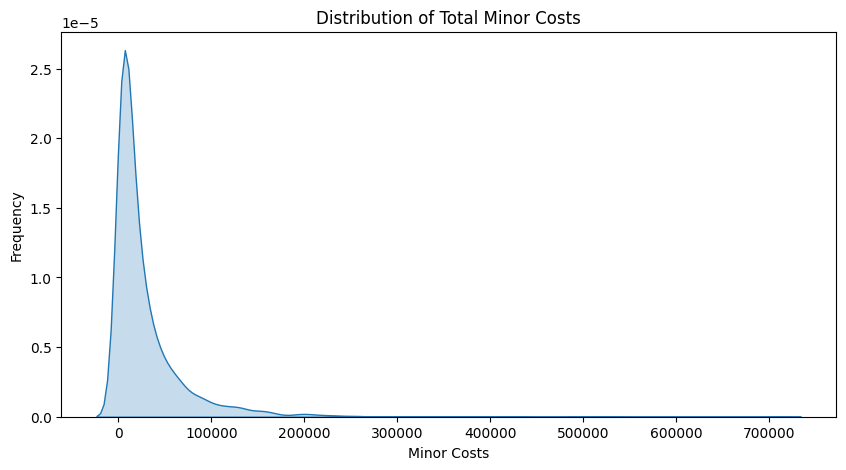

In [233]:
plt.figure(figsize=(10,5))
sns.kdeplot(df1['TOTMCST'], fill=True)

plt.title('Distribution of Total Minor Costs')
plt.xlabel('Minor Costs')
plt.ylabel('Frequency')


### Duplicates

In [234]:
df1.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9100    False
9101    False
9102    False
9103    False
9104    False
Length: 9105, dtype: bool

In [235]:
df1.duplicated().any()

np.False_

In [236]:
df1.duplicated().sum()    # Count duplicates in the dataset

np.int64(0)

In [237]:
df1[df1.duplicated()]     # See duplicate rows

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,CREA,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC


There are no duplicate rows and in the dataset. duplicates found in columns are instances of non-unique values, not necessarily input errors

## Exploratory Data Analysis

### Univariate Analysis

In [238]:
df1

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,CREA,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC
0,1,62,0,male,0,5,2029 days,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,NaN,7.000000
1,2,60,1,female,1,4,4 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,<2 mo. follow-up,1.000000
2,3,52,1,female,0,17,47 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,6.51,2502.0,1.0,0.0,<2 mo. follow-up,0.000000
3,4,42,1,female,0,3,133 days,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,6.51,2502.0,0.0,0.0,no(M2 and SIP pres),0.000000
4,5,79,0,female,0,16,2029 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,no(M2 and SIP pres),2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,9101,66,0,male,0,23,350 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.099854,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,NaN,0.000000
9101,9102,55,0,female,0,29,347 days,Coma,Coma,1,...,5.899414,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,NaN,0.000000
9102,9103,70,0,male,0,8,346 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,2.699707,139.0,7.379883,189.0,60.00,3900.0,NaN,NaN,NaN,2.525391
9103,9104,47,1,male,1,7,7 days,MOSF w/Malig,ARF/MOSF,1,...,3.500000,135.0,7.469727,246.0,55.00,2502.0,NaN,0.0,<2 mo. follow-up,0.000000


#### 1. What is the distribution of PRG2M and PRG6M? What do their average values indicate about the short and long term survival rates of patients?

In [323]:
df1['PRG2M'].describe()

count    7456.000000
mean        0.618769
std         0.298367
min         0.000000
25%         0.500000
50%         0.700000
75%         0.900000
max         1.000000
Name: PRG2M, dtype: float64

In [327]:
df1['PRG6M'].describe()

count    7472.000000
mean        0.499679
std         0.304367
min         0.000000
25%         0.200000
50%         0.500000
75%         0.750000
max         1.000000
Name: PRG6M, dtype: float64

Text(0, 0.5, 'Count')

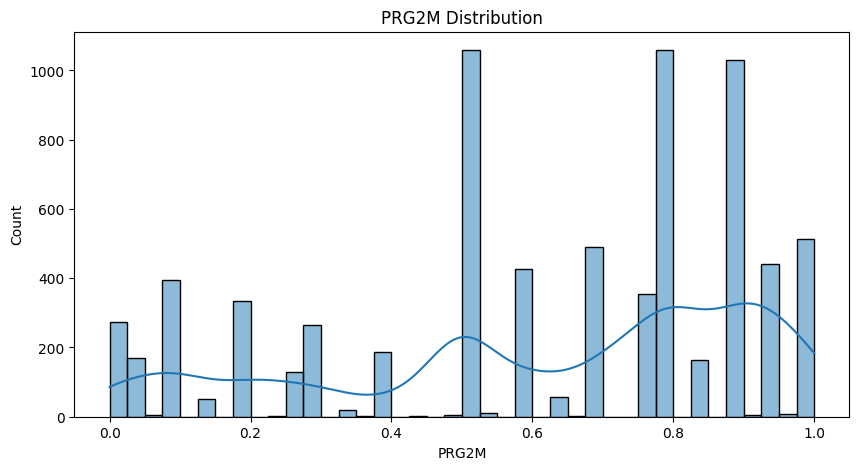

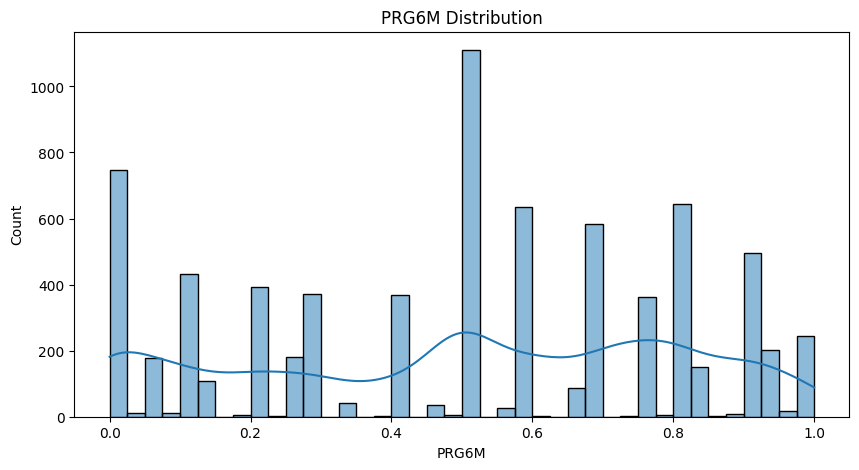

In [326]:
# Plot a histogram and KDE

plt.figure(figsize=(10,5))
sns.histplot(data=df1,
             x='PRG2M',
             kde=True,
            bins=40)
plt.title('PRG2M Distribution')
plt.xlabel('PRG2M')
plt.ylabel('Count')

# Plot a histogram and KDE

plt.figure(figsize=(10,5))
sns.histplot(data=df1,
             x='PRG6M',
             kde=True,
            bins=40)
plt.title('PRG6M Distribution')
plt.xlabel('PRG6M')
plt.ylabel('Count')

Summary:
Proportion of patients with PRG2M and PRG6M estimates. Graphs show averages of 0.61 and 0.49 respectively

#### 2. What does the age distribution of patients say about age related patterns in the dataset?

In [239]:
df1['AGE'].describe()     # Numerical Statistical description

count    9105.000000
mean       62.151016
std        15.600845
min        18.000000
25%        52.000000
50%        64.000000
75%        73.000000
max       101.000000
Name: AGE, dtype: float64

Average age is 62 years old. 

In [240]:
age=df1['AGE'].value_counts().sort_values(ascending=False)
age

AGE
68     272
66     264
65     262
70     261
71     259
      ... 
97       5
100      4
99       2
98       1
101      1
Name: count, Length: 84, dtype: int64

Text(0, 0.5, 'Count')

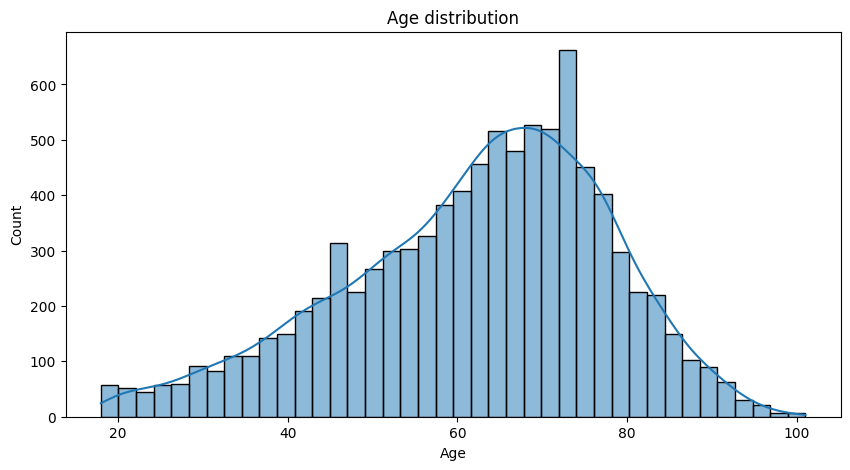

In [241]:
# Plot a histogram and KDE

plt.figure(figsize=(10,5))
sns.histplot(data=df1,
             x='AGE',
             kde=True,
            bins=40)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

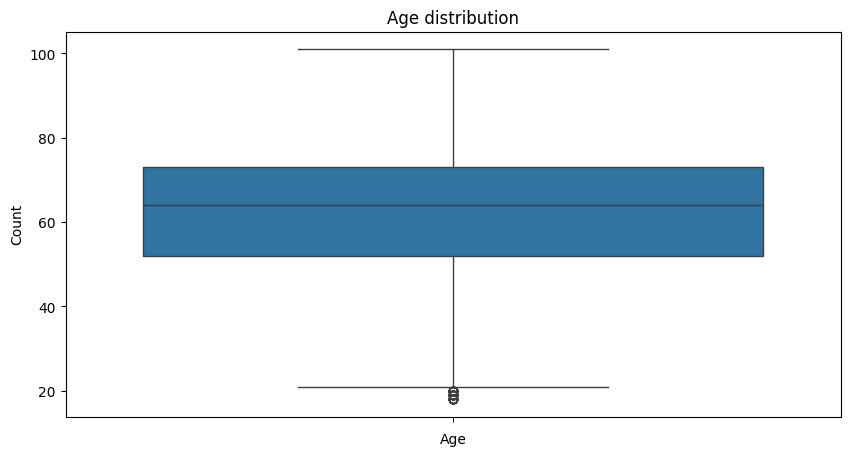

In [242]:
# Box plot to investigate age distribution
plt.figure(figsize=(10,5))
sns.boxplot(data=df1['AGE'])

plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')

Outliers fall under the 20 mark. Age distribution falls within 50 and 75 years 

In [243]:
df1['AGE'].median()

np.float64(64.0)

In [245]:
df1['AGE'].mean()

np.float64(62.15101592531576)

In [244]:
df1['AGE'].mode()

0    68
Name: AGE, dtype: int64

Age Distribution skews slightly to the right, comparing values of mean and median

In [246]:
# Find the interquartile range
df1['AGE'].describe()

count    9105.000000
mean       62.151016
std        15.600845
min        18.000000
25%        52.000000
50%        64.000000
75%        73.000000
max       101.000000
Name: AGE, dtype: float64

In [247]:
IQR=73.000000-52.000000
upper_limit = 73.000000 + 1.5*IQR
lower_limit = 52.000000 - 1.5*IQR
print(IQR)
print(upper_limit)
print(lower_limit)

21.0
104.5
20.5


Summary:
1. Average age is 62 years old.
2. Median age is 64 years old.
3. Histogram reveals an almost normal distribution, with a slight skew to the right. Indicates the age range most patients fall under.
4. Outliers fall under the 20 mark. Age distribution falls within 50 and 75 years.
5. Age Distribution skews slightly to the right, comparing values of mean and median. Indicates most patient ages are clustered at the lower end of the distribution, although they are closer to the average

#### 3. What findings are discoverd in exploring the distribution of patient hospital deaths?

In [248]:
df1['HOSPDEAD'].value_counts()

HOSPDEAD
0    6745
1    2360
Name: count, dtype: int64

Text(0, 0.5, 'Count')

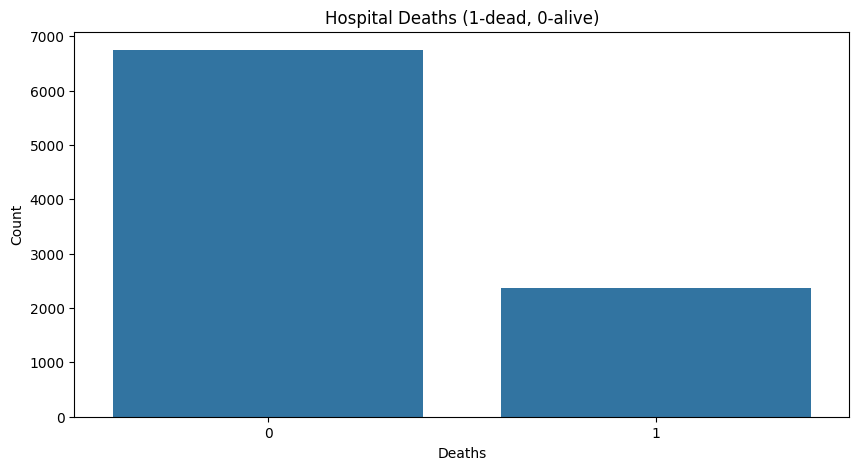

In [448]:
# Visualize
plt.figure(figsize=(10,5))
sns.countplot(df1,
              x='HOSPDEAD')
plt.title('Hospital Deaths (1-dead, 0-alive)')
plt.xlabel('Deaths')
plt.ylabel('Count')


Summary:More patients who arrive in the hospital die there

#### 4. How does patient sex impact survival rates?

In [442]:
# Sex Distribution
df1['SEX'].describe()

count     9105
unique       2
top       male
freq      5125
Name: SEX, dtype: object

In [443]:
df1['SEX'].value_counts()

SEX
male      5125
female    3980
Name: count, dtype: int64

In [444]:
sex_df=df1['SEX'].value_counts().reset_index()
sex_df.columns=['Sex', 'Count']
sex_df

,Sex,Count
0,male,5125
1,female,3980


Text(0, 0.5, 'Count')

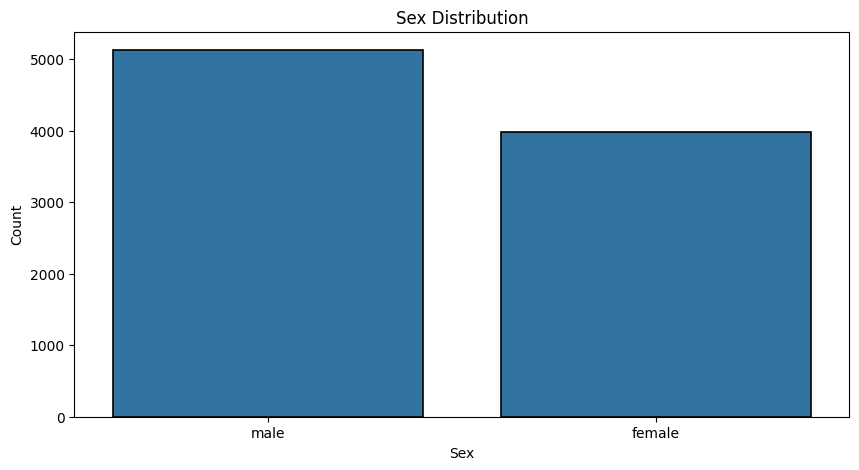

In [447]:
# Visualise using a bar chart

plt.figure(figsize=(10,5))
sns.barplot(sex_df,
            x='Sex',
            y='Count',
           edgecolor='black',
            linewidth=1.2)
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')

Larger proportion of males exist as patients compared to female counterparts

#### 5. What does the distribution of disease groups and classes patients fall under reveal?

In [449]:
df1['DZGROUP'].value_counts()

DZGROUP
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64

In [454]:
df1['DZCLASS'].value_counts()

DZCLASS
ARF/MOSF              4227
COPD/CHF/Cirrhosis    2862
Cancer                1420
Coma                   596
Name: count, dtype: int64

([0, 1, 2, 3],
 [Text(0, 0, 'Cancer'),
  Text(1, 0, 'COPD/CHF/Cirrhosis'),
  Text(2, 0, 'ARF/MOSF'),
  Text(3, 0, 'Coma')])

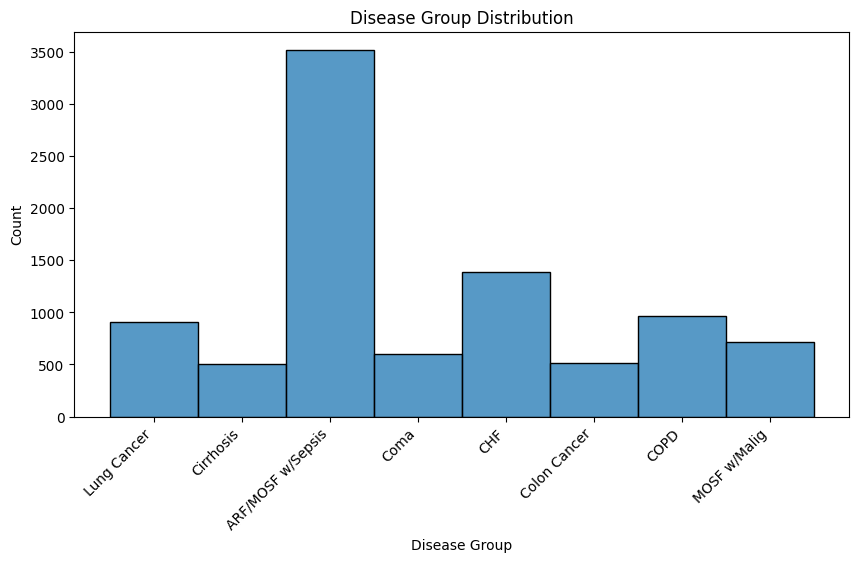

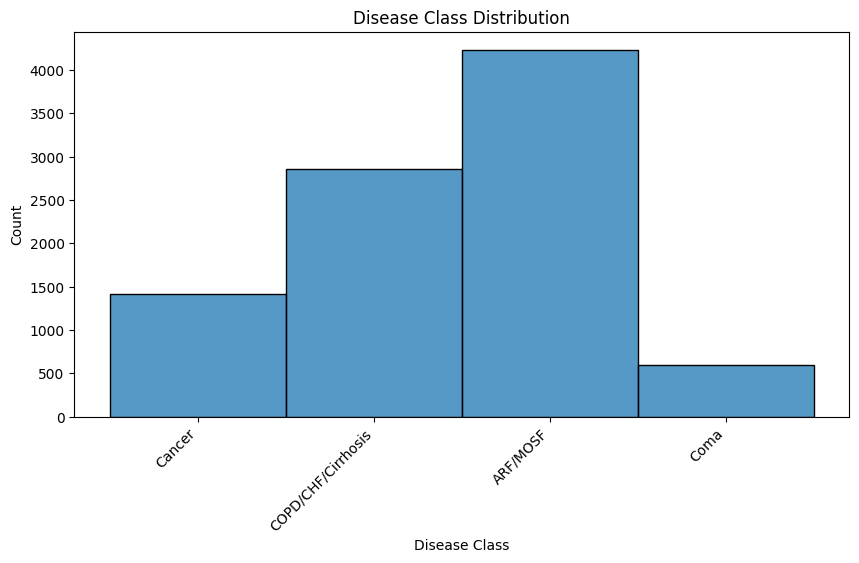

In [455]:
# Plot a histogram and KDE for disease groups

plt.figure(figsize=(10,5))
sns.histplot(data=df1,
             x='DZGROUP',
            bins=40)
plt.title('Disease Group Distribution')
plt.xlabel('Disease Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')


plt.figure(figsize=(10,5))
sns.histplot(data=df1,
             x='DZCLASS',
            bins=40)
plt.title('Disease Class Distribution')
plt.xlabel('Disease Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

1. ARF/MOSF/w/SEPSIS is the largest disease group whilst ARF/MOSF form the largest disease class.
2. The dataset is heavily skewed toward patients with acute respiratory failure / multi-organ system failure with sepsis. That means any models will be influenced strongly by this group. 3500 cases are recorded.
3. The same can be said about patients with Acute Respiratory Failure / Multi-Organ System Failure. Over 4000 cases are recorded.

Summary:
1. Most patients are diagnosed with acute respiratory failure / multi-organ system failure with sepsis, the highest disease group.
2. Many of those patients also come in with Acute Respiratory Failure / Multi-Organ System Failure, which is the highest disease class

#### 6. What is the distribution of Comorbidities in the dataset?

In [456]:
df1['NUM.CO'].value_counts()

NUM.CO
1    3006
2    2397
3    1425
0    1177
4     714
5     263
6      98
7      21
8       3
9       1
Name: count, dtype: int64

In [458]:
df1['NUM.CO'].describe()

count    9105.000000
mean        1.868644
std         1.344409
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: NUM.CO, dtype: float64

Text(0, 0.5, 'Count')

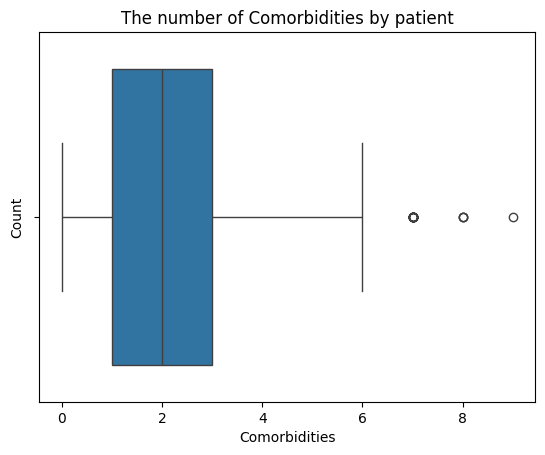

In [463]:
# Visualize
sns.boxplot(df1,
              x='NUM.CO')
plt.title('The number of Comorbidities by patient')
plt.xlabel('Comorbidities')
plt.ylabel('Count')

Summary: Many patients record one to three comorbidities, an average of two comorbidities. Outliers represent patients with more than six comorbidities

### Bivariate Analysis

In [250]:
df1

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,CREA,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC
0,1,62,0,male,0,5,2029 days,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,NaN,7.000000
1,2,60,1,female,1,4,4 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,<2 mo. follow-up,1.000000
2,3,52,1,female,0,17,47 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,6.51,2502.0,1.0,0.0,<2 mo. follow-up,0.000000
3,4,42,1,female,0,3,133 days,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,6.51,2502.0,0.0,0.0,no(M2 and SIP pres),0.000000
4,5,79,0,female,0,16,2029 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,no(M2 and SIP pres),2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,9101,66,0,male,0,23,350 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.099854,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,NaN,0.000000
9101,9102,55,0,female,0,29,347 days,Coma,Coma,1,...,5.899414,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,NaN,0.000000
9102,9103,70,0,male,0,8,346 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,2.699707,139.0,7.379883,189.0,60.00,3900.0,NaN,NaN,NaN,2.525391
9103,9104,47,1,male,1,7,7 days,MOSF w/Malig,ARF/MOSF,1,...,3.500000,135.0,7.469727,246.0,55.00,2502.0,NaN,0.0,<2 mo. follow-up,0.000000


#### 1. Which age category(ies) are associated with higher hospital deaths?

Text(0, 0.5, 'Hospital Deaths')

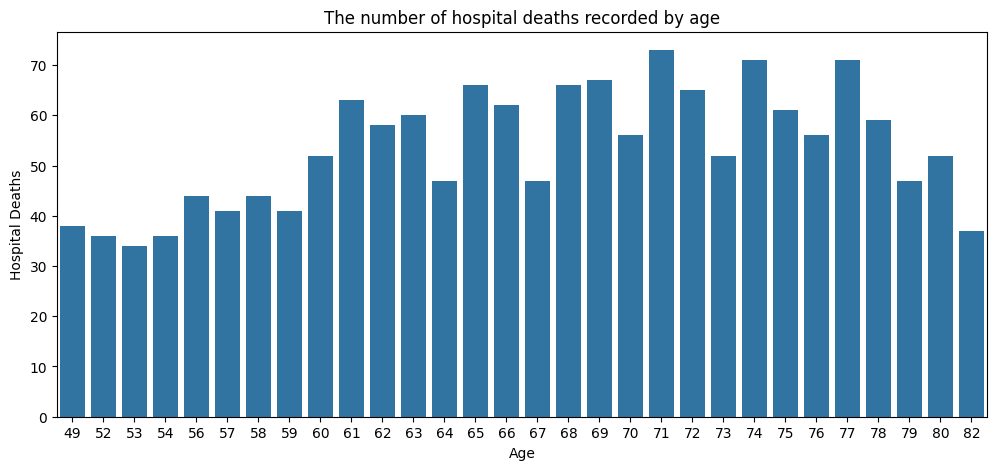

In [251]:
age_death=df1.groupby('AGE')['HOSPDEAD'].sum().sort_values(ascending=False).head(30)   # Category recording highest hospital deaths

# Convert to dataframe to visualise
age_death_df=age_death.reset_index()
age_death_df.columns=['AGE', 'HOSPITAL DEATHS']

plt.figure(figsize=(12,5))     # Bar plot
sns.barplot(age_death_df,
           x='AGE',
           y='HOSPITAL DEATHS'
           )
plt.title('The number of hospital deaths recorded by age')
plt.xlabel('Age')
plt.ylabel('Hospital Deaths')


Patients aged 71 years on record died the most whilst 53 year olds died the least. 71 is the ideal age category to make the necessary interventions

<Axes: title={'center': 'The number of hospital deaths recorded by age'}, xlabel='AGE', ylabel='HOSPITAL DEATHS'>

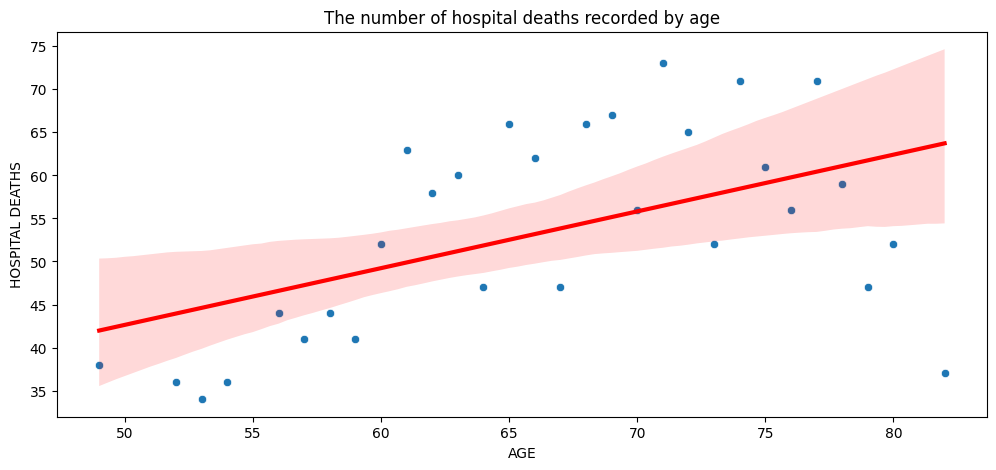

In [252]:
# Determine correlation between age and deaths recorded
plt.figure(figsize=(12,5))
sns.scatterplot(data=age_death_df,
                x='AGE',
                y='HOSPITAL DEATHS')
plt.title('The number of hospital deaths recorded by age')
plt.xlabel('Age')
plt.ylabel('Hospital Deaths')


sns.regplot(
    data=age_death_df,
    x='AGE',
    y='HOSPITAL DEATHS',
    scatter=False,
    line_kws={'linewidth': 3, 'color': 'red'} 
)

Scatter plot shows how as the age increases, hospital deaths increase, till at 70 years. Trend shows a decrease in hospital deaths after 70

#### 2. What does the relationship between the number of patient comorbidities and its impact on the number of hospital mortality rates reveal?

In [253]:
# Draw a correlation matrix
# Contingency table
cont_table=pd.crosstab(df1['NUM.CO'], df1['HOSPDEAD'])
cont_table

HOSPDEAD,0,1
NUM.CO,,
0,795,382
1,2180,826
2,1782,615
3,1113,312
4,569,145
5,202,61
6,81,17
7,19,2
8,3,0


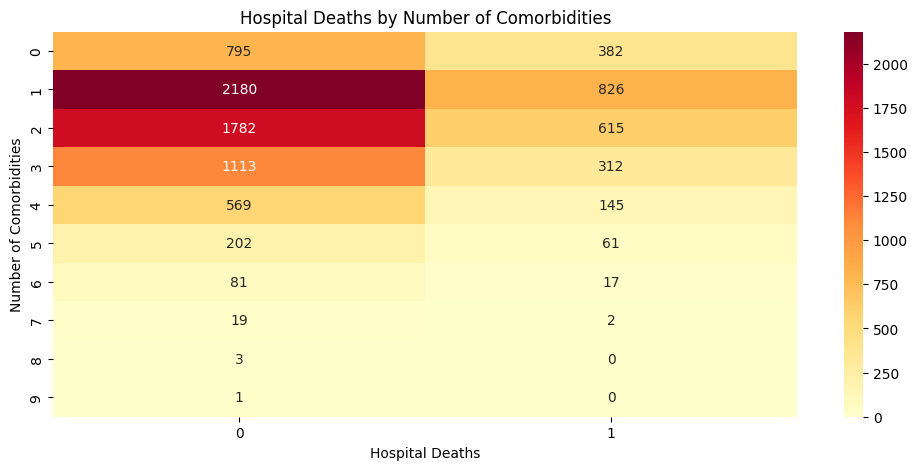

In [254]:
# Heatmap to visualize hospital deaths by number of comorbidities

plt.figure(figsize=(12,5))
sns.heatmap(cont_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Hospital Deaths by Number of Comorbidities')
plt.xlabel('Hospital Deaths')
plt.ylabel('Number of Comorbidities')
plt.show()


Patients acquitted even with one, two and three disease/comorbidity value had a stronger chance of dying 

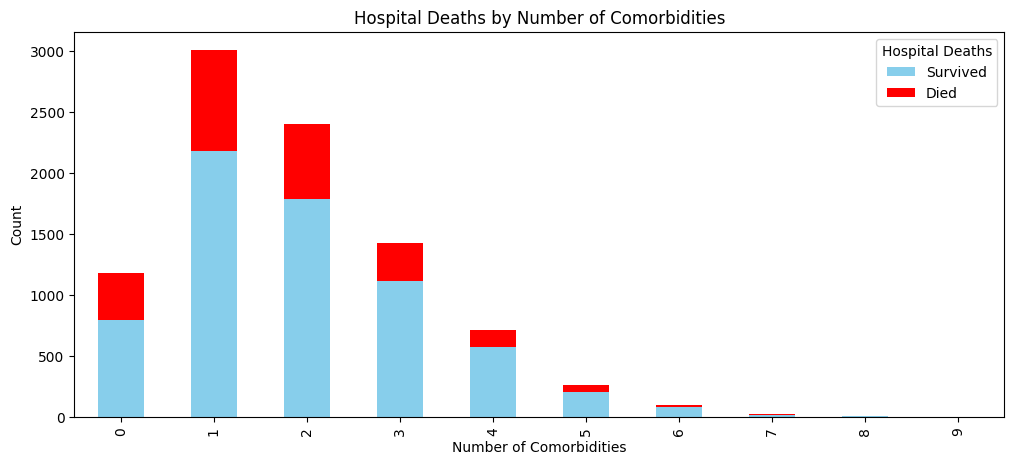

In [255]:
# Stacked bar plot to visualize hospital deaths by number of comorbidities
cont_table.plot(kind='bar', 
                stacked=True, 
                figsize=(12,5),
                color=['skyblue','red'])
plt.title('Hospital Deaths by Number of Comorbidities')
plt.xlabel('Number of Comorbidities')
plt.ylabel('Count')
plt.legend(title='Hospital Deaths', labels=['Survived', 'Died'])
plt.show()


#### 3. How do the ages of the patients relate to their two and six month survival outcomes?

In [476]:
age_critical=df1[df1['AGE'].between(55,80)]  # Filter age range most patients fall under
age_critical

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,CREA,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC
0,1,62,0,male,0,5,2029 days,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,NaN,7.000000
1,2,60,1,female,1,4,4 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,<2 mo. follow-up,1.000000
4,5,79,0,female,0,16,2029 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,no(M2 and SIP pres),2.000000
6,7,62,1,male,0,9,659 days,CHF,COPD/CHF/Cirrhosis,1,...,1.599854,132.0,7.479492,NaN,6.51,2502.0,0.0,1.0,no(M2 and SIP pres),1.000000
11,12,59,1,male,1,13,13 days,Lung Cancer,Cancer,0,...,1.099854,136.0,NaN,NaN,6.51,2502.0,1.0,1.0,<2 mo. follow-up,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9098,9099,70,1,male,0,15,17 days,ARF/MOSF w/Sepsis,ARF/MOSF,4,...,1.199951,136.0,7.419922,179.0,22.00,2010.0,NaN,NaN,<2 mo. follow-up,2.714844
9099,9100,68,0,female,0,4,353 days,COPD,COPD/CHF/Cirrhosis,2,...,0.799927,128.0,7.489258,142.0,17.00,950.0,0.0,NaN,no(M2 and SIP pres),0.494751
9100,9101,66,0,male,0,23,350 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.099854,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,NaN,0.000000
9101,9102,55,0,female,0,29,347 days,Coma,Coma,1,...,5.899414,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,NaN,0.000000


Text(0, 0.5, 'Survival Probability')

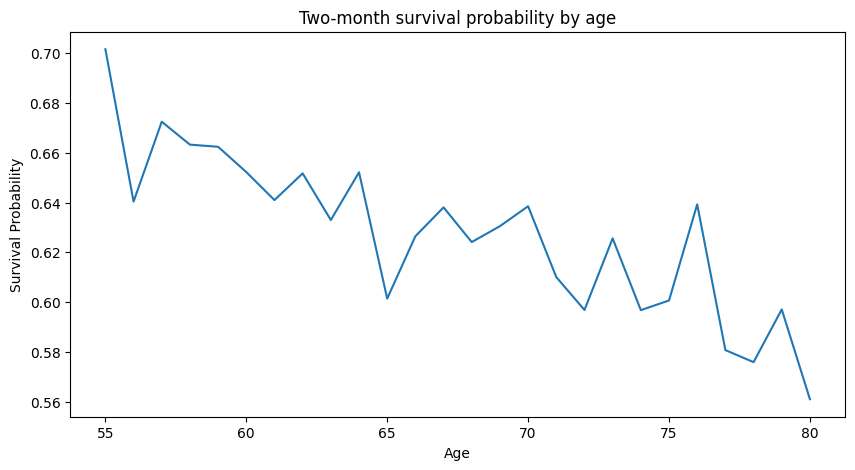

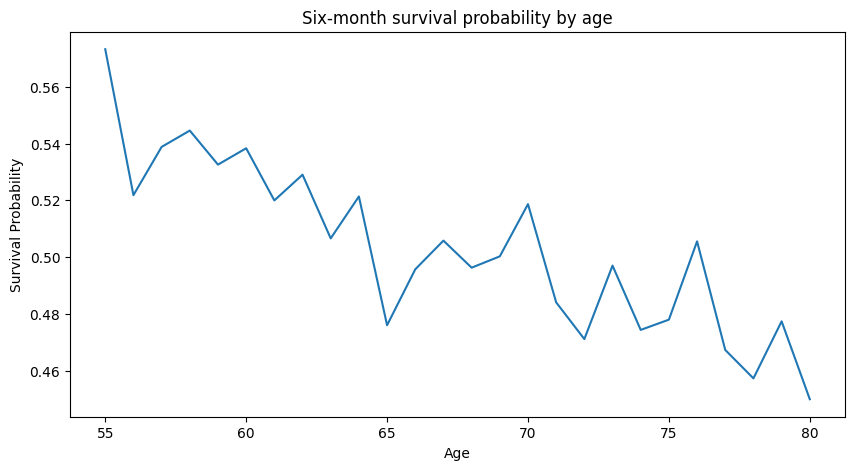

In [488]:
# Aggregate survival by age
age_summary = age_critical.groupby('AGE')[['SURV2M', 'SURV6M']].mean().reset_index()

# Plot 2-month survival
plt.figure(figsize=(10,5))
sns.lineplot(data=age_summary, x='AGE', y='SURV2M')
plt.title('Two-month survival probability by age')
plt.xlabel('Age')
plt.ylabel('Survival Probability')

# Plot 6-month survival
plt.figure(figsize=(10,5))
sns.lineplot(data=age_summary, x='AGE', y='SURV6M')
plt.title('Six-month survival probability by age')
plt.xlabel('Age')
plt.ylabel('Survival Probability')


Probability of survival reduces with age. Within the considered cluster of patient ages, the chances that a patient will survive with two and six months tends to decrease.

#### 4. Which disease classes illustrate the short and long term chances of survival of patients(two and six months respectively)?

Text(0, 0.5, 'Probability of Survival')

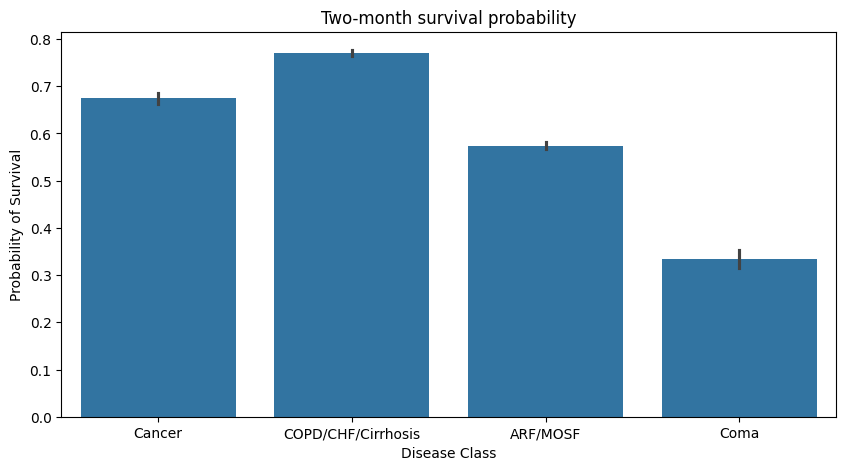

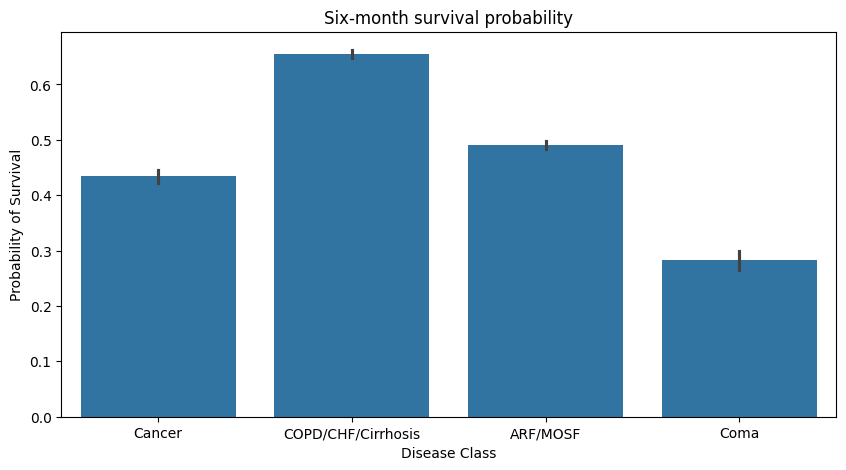

In [495]:
# Disease class by two and six month survival rate

plt.figure(figsize=(10,5))
sns.barplot(df1, 
             x='DZCLASS',
             y='SURV2M')
plt.title('Two-month survival probability')
plt.xlabel('Disease Class')
plt.ylabel('Probability of Survival')

plt.figure(figsize=(10,5))
sns.barplot(df1, 
             x='DZCLASS',
             y='SURV6M')
plt.title('Six-month survival probability')
plt.xlabel('Disease Class')
plt.ylabel('Probability of Survival')


About 2700 patients with COPD/CHF/Cirrhosis have a strong chance of surviving within two and six months, even though more patients (above 4000) suffer from ARF/MOSF.

#### 5. How does a patient's physiology score influence his/her chances of survival?

Text(0, 0.5, 'Probability of Survival')

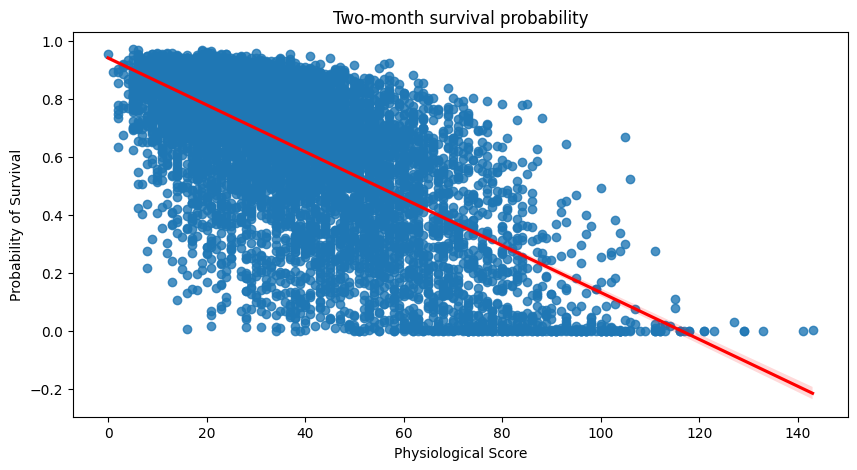

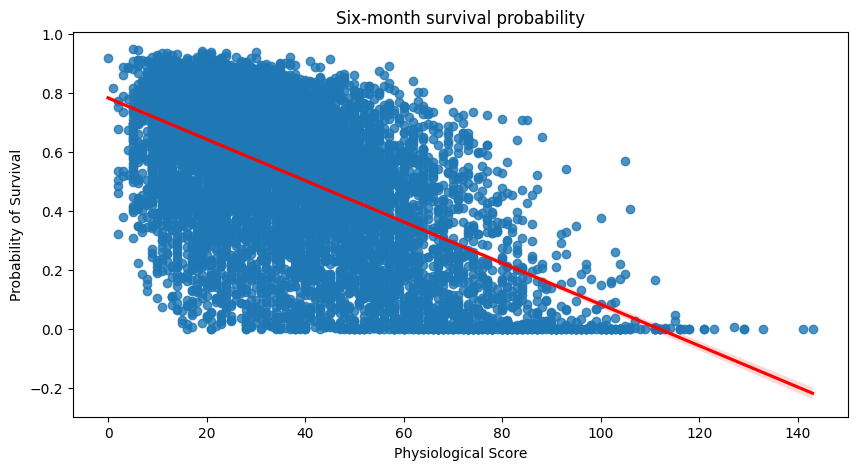

In [500]:
# Relating physiological score to the short and long term chances of survival

plt.figure(figsize=(10,5))
sns.regplot(df1, 
             x='APS',
             y='SURV2M',
           line_kws={'color':'red'})
plt.title('Two-month survival probability')
plt.xlabel('Physiological Score')
plt.ylabel('Probability of Survival')

plt.figure(figsize=(10,5))
sns.regplot(df1, 
             x='APS',
             y='SURV6M',
           line_kws={'color':'red'})
plt.title('Six-month survival probability')
plt.xlabel('Physiological Score')
plt.ylabel('Probability of Survival')

In the short and long terms, an increase in the physiological score corresponds to a decrease in the chances of survival. Higher physiological scores indicate worse physiological conditions

Summary:
1. The APS is a strong predictor of short and long term mortality

#### 6. How does a patient's race impact physician’s 2 and 6 month survival estimates?

In [280]:
# Relationship between race and prg2m
df1['RACE'].value_counts()          # Race count

RACE
white       7191
black       1391
hispanic     290
other        112
asian         79
Name: count, dtype: int64

In [257]:
# Group race by 2 month survival estimate
df1.groupby('RACE')['PRG2M'].value_counts()

RACE   PRG2M
asian  0.50     11
       0.60      7
       0.80      7
       0.10      6
       0.05      4
                ..
white  0.53      1
       0.76      1
       0.77      1
       0.79      1
       0.83      1
Name: count, Length: 136, dtype: int64

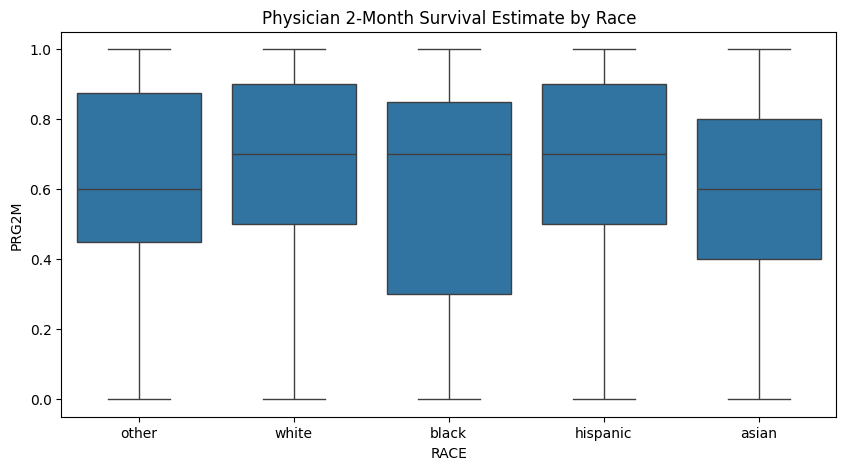

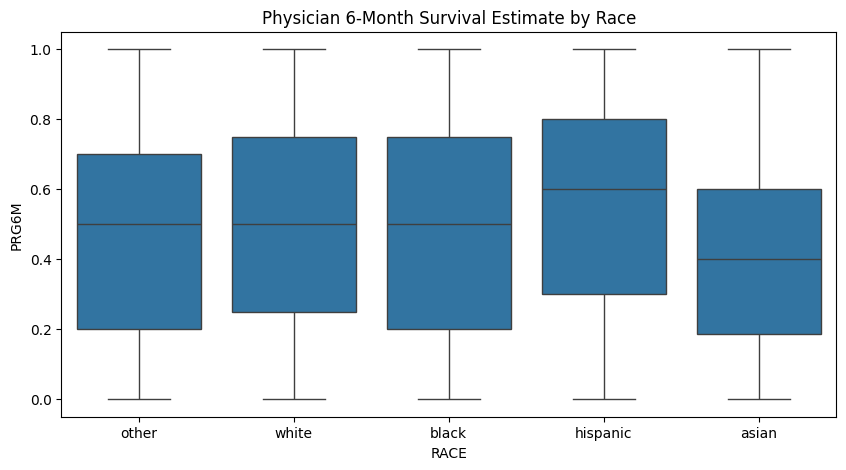

In [509]:
# Draw a box plot
plt.figure(figsize=(10,5))
sns.boxplot(df1,
            x='RACE',
            y='PRG2M')
plt.title('Physician 2-Month Survival Estimate by Race')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df1,
            x='RACE',
            y='PRG6M')
plt.title('Physician 6-Month Survival Estimate by Race')
plt.show()

Summary:
1. The range of estimates are wide and almost equal. Physicians however assign lower estimated 2-month survival probabilities to Black patients than to White, Hispanic, Asian, or Other patients, even though the overall range of estimates is similarly wide in every racial group.
2. For 6 month estimates, range is still wide and very equal. However, dire black patient predictions disappear. Asians record the lowest median predictions while hispanics receive the highest rates.

Provide medical interventions to blacks in the short term and to asians in the long term.

# Box plots to visualize short term and long term survival rates (SURV2M and SURV6M)
plt.figure(figsize=(10,5))
sns.boxplot(df1,
            x='RACE',
            y='SURV2M')
plt.title('Physician 2-Month Survival Estimate by Race')
plt.xlabel('RACE')
plt.ylabel('SURV2M')

plt.figure(figsize=(10,5))
sns.boxplot(df1,
            x='RACE',
            y='SURV6M')
plt.title('Physician 6-Month Survival Estimate by Race')
plt.xlabel('RACE')
plt.ylabel('SURV6M')

Summary:
1. The model makes race neutral predictions and the median values are quite uniform across races.
2. Outliers in the 2 month prognosis could refer to individuals with high comorbidity rates
3. Race holds no substantive predictive power. Race disparities observed above could be explained by physician bias or clinically unrelated issues

In [279]:
# Group race by 6 month survival estimate
df1.groupby('RACE')['PRG6M'].value_counts()

RACE   PRG6M
asian  0.500    11
       0.400     6
       0.200     5
       0.050     4
       0.100     4
                ..
white  0.857     1
       0.870     1
       0.890     1
       0.910     1
       0.941     1
Name: count, Length: 202, dtype: int64

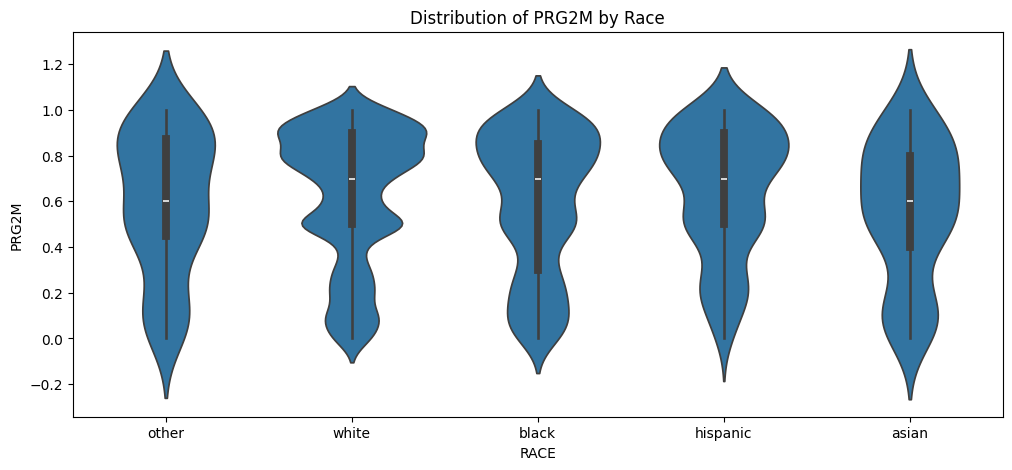

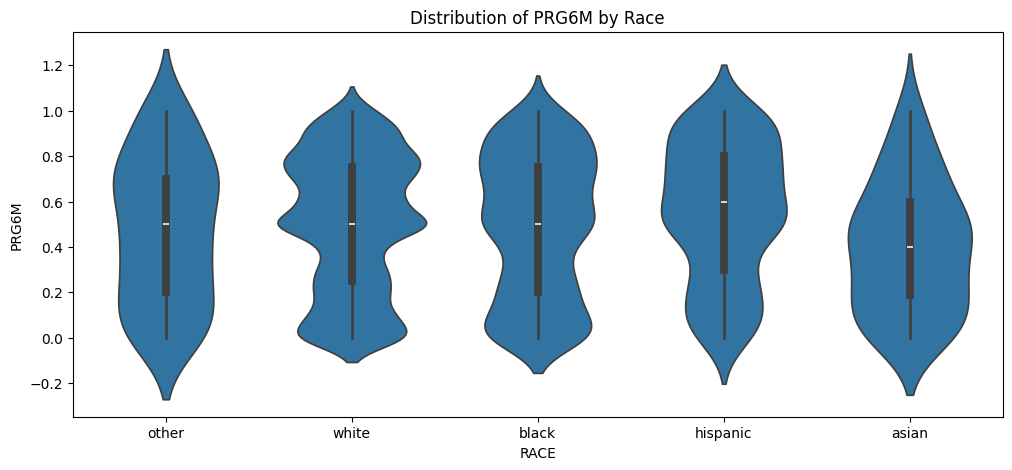

In [285]:
# Plot violin plot

plt.figure(figsize=(12,5))
sns.violinplot(data=df1, x='RACE', y='PRG2M')
plt.title('Distribution of PRG2M by Race')
plt.show()

plt.figure(figsize=(12,5))
sns.violinplot(data=df1, x='RACE', y='PRG6M')
plt.title('Distribution of PRG6M by Race')
plt.show()

#### 7. How do short and long term survival rates (by model or physician) impact gender?

Text(0, 0.5, '6-month Survival rates')

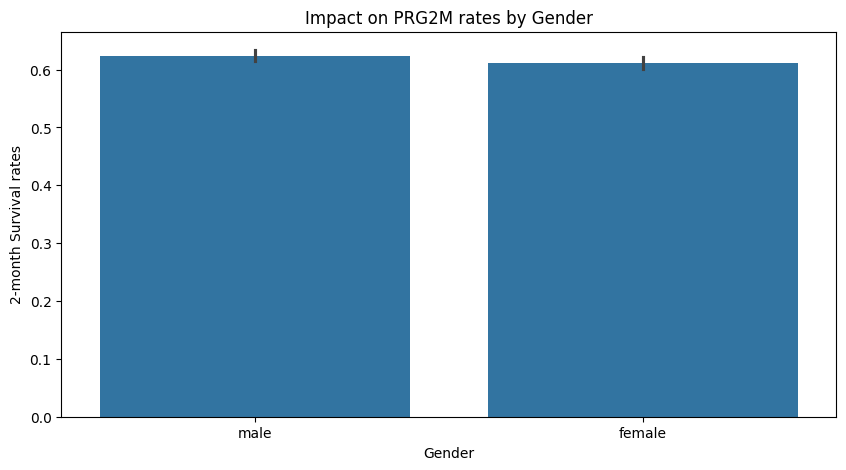

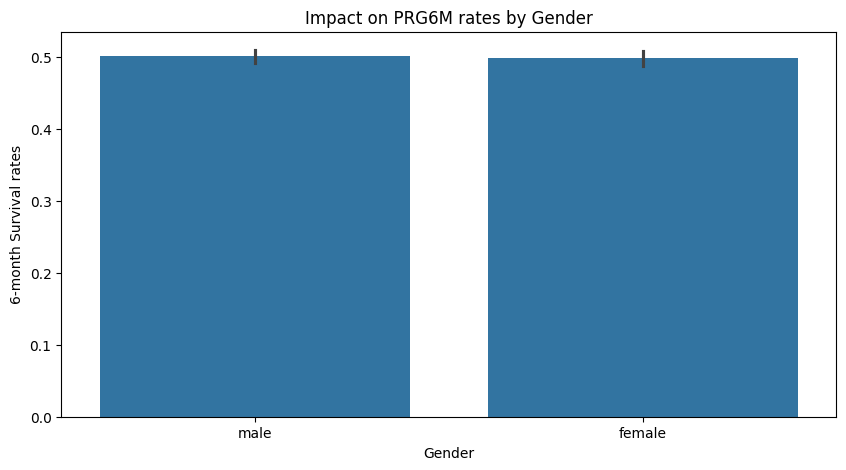

In [512]:
plt.figure(figsize=(10,5))        # Impact on prg2m rates (Physician)
sns.barplot(df1,
           x='SEX',
           y='PRG2M')
plt.title('Impact on PRG2M rates by Gender')
plt.xlabel('Gender')
plt.ylabel('2-month Survival rates')

plt.figure(figsize=(10,5))        # Impact on prg2m rates
sns.barplot(df1,
           x='SEX',
           y='PRG6M')
plt.title('Impact on PRG6M rates by Gender')
plt.xlabel('Gender')
plt.ylabel('6-month Survival rates')


Text(0, 0.5, '6-month Survival rates')

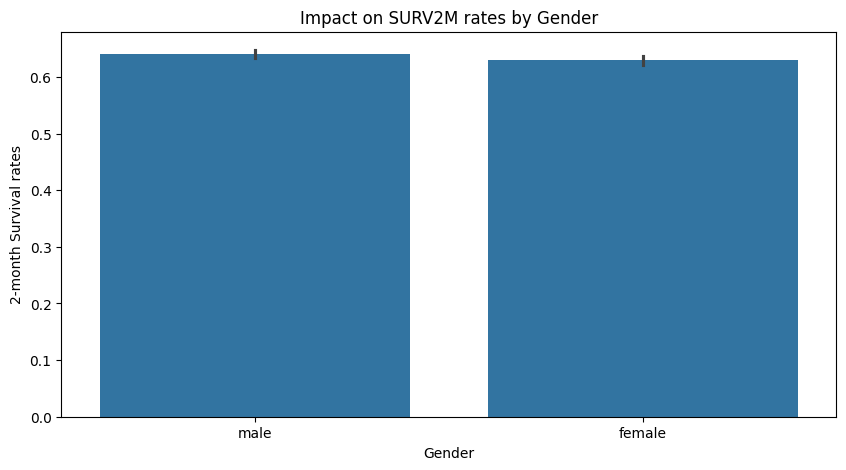

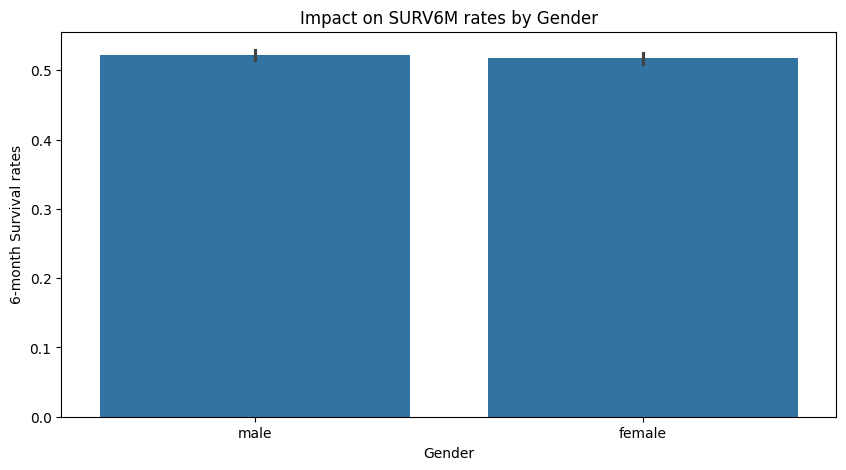

In [513]:
plt.figure(figsize=(10,5))        # Impact on prg2m rates (Model)
sns.barplot(df1,
           x='SEX',
           y='SURV2M')
plt.title('Impact on SURV2M rates by Gender')
plt.xlabel('Gender')
plt.ylabel('2-month Survival rates')

plt.figure(figsize=(10,5))        # Impact on prg2m rates
sns.barplot(df1,
           x='SEX',
           y='SURV6M')
plt.title('Impact on SURV6M rates by Gender')
plt.xlabel('Gender')
plt.ylabel('6-month Survival rates')


Summary:
1. Gender holds no relevance or predictive power in survival rates by model or physicians

#### 8. How do glucose levels correlate with diabetes comorbidity?

In [302]:
df1

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC,PRG2M_bin
0,1,62,0,male,0,5,2029 days,Lung Cancer,Cancer,0,...,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,NaN,7.000000,"(0.4, 0.6]"
1,2,60,1,female,1,4,4 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,<2 mo. follow-up,1.000000,"(-0.001, 0.2]"
2,3,52,1,female,0,17,47 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,134.0,7.459961,NaN,6.51,2502.0,1.0,0.0,<2 mo. follow-up,0.000000,"(0.6, 0.8]"
3,4,42,1,female,0,3,133 days,Lung Cancer,Cancer,2,...,139.0,NaN,NaN,6.51,2502.0,0.0,0.0,no(M2 and SIP pres),0.000000,"(0.8, 1.0]"
4,5,79,0,female,0,16,2029 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,no(M2 and SIP pres),2.000000,"(0.8, 1.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,9101,66,0,male,0,23,350 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,NaN,0.000000,"(0.6, 0.8]"
9101,9102,55,0,female,0,29,347 days,Coma,Coma,1,...,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,NaN,0.000000,"(0.4, 0.6]"
9102,9103,70,0,male,0,8,346 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,139.0,7.379883,189.0,60.00,3900.0,NaN,NaN,NaN,2.525391,"(0.8, 1.0]"
9103,9104,47,1,male,1,7,7 days,MOSF w/Malig,ARF/MOSF,1,...,135.0,7.469727,246.0,55.00,2502.0,NaN,0.0,<2 mo. follow-up,0.000000,"(-0.001, 0.2]"


In [294]:
df1[['GLUCOSE', 'DIABETES']]

,GLUCOSE,DIABETES
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0
...,...,...
9100,188.0,0
9101,190.0,0
9102,189.0,0
9103,246.0,0


In [298]:
df1['GLUCOSE'].isna().mean()*100  # Percentage of missing values

np.float64(49.42339373970346)

Almost 50% of values in glucose column are missing

In [303]:
# Check to see if correlation is safe to perform
df1[['GLUCOSE','DIABETES']].dropna().shape

(4605, 2)

In [305]:
df1['GLUCOSE'].corr(df1['DIABETES'])

np.float64(0.026168276035594903)

There is no correlation between glucose levels in day 3 and diabetes. Consider dropping Glucose column

In [307]:
df1.drop(['PRG2M_bin'], axis=1)

,ID,AGE,DEATH,SEX,HOSPDEAD,SLOS,D.TIME,DZGROUP,DZCLASS,NUM.CO,...,CREA,SOD,PH,GLUCOSE,BUN,URINE,ADLP,ADLS,SFDM2,ADLSC
0,1,62,0,male,0,5,2029 days,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,NaN,7.000000
1,2,60,1,female,1,4,4 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,<2 mo. follow-up,1.000000
2,3,52,1,female,0,17,47 days,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,6.51,2502.0,1.0,0.0,<2 mo. follow-up,0.000000
3,4,42,1,female,0,3,133 days,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,6.51,2502.0,0.0,0.0,no(M2 and SIP pres),0.000000
4,5,79,0,female,0,16,2029 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,no(M2 and SIP pres),2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,9101,66,0,male,0,23,350 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.099854,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,NaN,0.000000
9101,9102,55,0,female,0,29,347 days,Coma,Coma,1,...,5.899414,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,NaN,0.000000
9102,9103,70,0,male,0,8,346 days,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,2.699707,139.0,7.379883,189.0,60.00,3900.0,NaN,NaN,NaN,2.525391
9103,9104,47,1,male,1,7,7 days,MOSF w/Malig,ARF/MOSF,1,...,3.500000,135.0,7.469727,246.0,55.00,2502.0,NaN,0.0,<2 mo. follow-up,0.000000


#### 9. Which physiological measure(s) correlates with survival at 2 and 6 months respectively?

How does Mean arterial blood pressure (MEANBP) correlate with 2 and 6 months survival rates respectively?

In [375]:
df1['MEANBP'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.08263768584567796)

In [376]:
df1['MEANBP'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.07152745630633531)

Very little correlation between blood pressure and survival rates

How do counts of white blood cells (WBLC) correlate with 2 and 6 months survival rates respectively?

In [377]:
df1['WBLC'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.06624259944912197)

In [380]:
df1['WBLC'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.027149892245025845)

Weak Correlation

How does Sodium concentration correlate with 2 and 6 month survival rates respectively?

In [379]:
df1['SOD'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.013477885351758798)

In [381]:
df1['SOD'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.0034162462407954994)

Weak correlation

In [383]:
df1['RESP'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.03509823973960269)

In [384]:
df1['RESP'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.021708539688185455)

In [385]:
df1['TEMP'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.06061220381873185)

In [387]:
df1['TEMP'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.030341117991219108)

In [388]:
df1['PH'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.0015803480338206933)

In [396]:
df1['PH'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.0022458541085456974)

In [392]:
df1['PAFI'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.11577573988323074)

In [397]:
df1['PAFI'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.05772854092316261)

In [394]:
df1['ALB'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.10930444133491812)

In [395]:
df1['ALB'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.058274857483488214)

In [398]:
df1['GLUCOSE'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.010385865913785309)

In [399]:
df1['GLUCOSE'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.003687184124239181)

In [400]:
df1['BILI'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.07842754484931798)

In [401]:
df1['BILI'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.04294920658780796)

In [402]:
df1['CREA'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.07025724660388444)

In [403]:
df1['CREA'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.04346224549442891)

In [404]:
df1['BUN'].corr(df1['PRG2M'], method='spearman') # Spearman method more ideal for medical data

np.float64(-0.028216016117164976)

In [405]:
df1['BUN'].corr(df1['PRG6M'], method='spearman') # Spearman method more ideal for medical data

np.float64(0.018378603659773955)

All record weak correlations!

#### 10. To what extent does the number of comorbidities predict 2 & 6 month survival?

In [406]:
df1[['NUM.CO', 'PRG2M']]

,NUM.CO,PRG2M
0,0,0.50
1,2,0.00
2,2,0.75
3,2,0.90
4,1,0.90
...,...,...
9100,1,0.80
9101,1,0.50
9102,1,0.90
9103,1,0.09


In [407]:
df1['NUM.CO'].value_counts()

NUM.CO
1    3006
2    2397
3    1425
0    1177
4     714
5     263
6      98
7      21
8       3
9       1
Name: count, dtype: int64

<Axes: xlabel='NUM.CO', ylabel='PRG6M'>

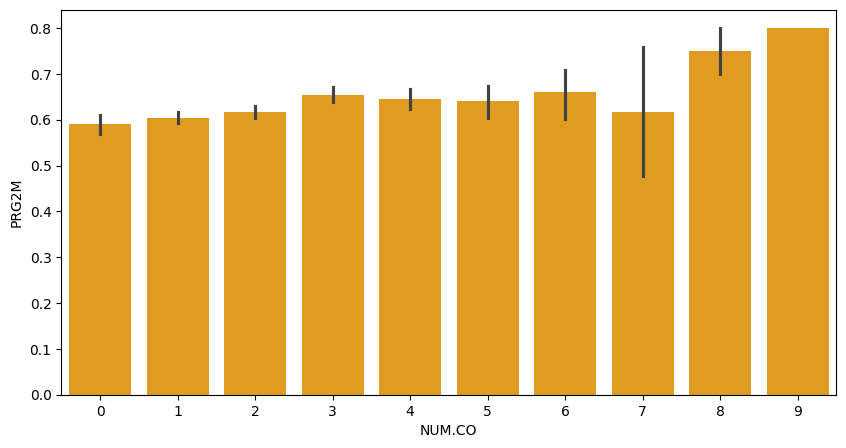

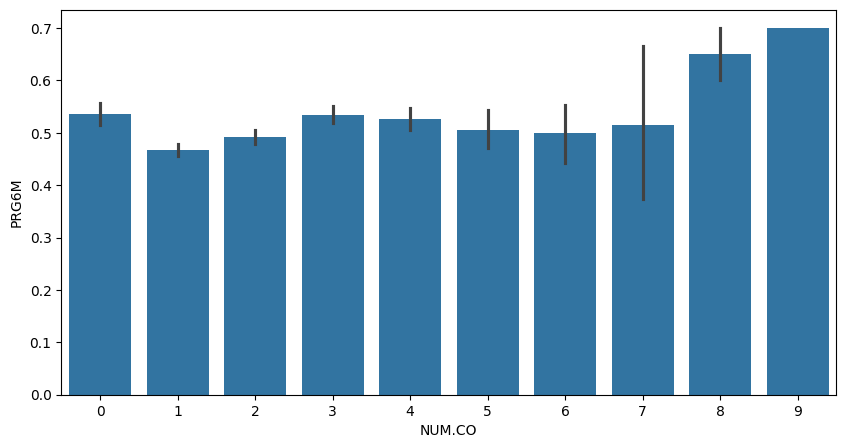

In [417]:
plt.figure(figsize=(10,5))
sns.barplot(df1,
           x='NUM.CO',
           y='PRG2M',
           color='orange')

plt.figure(figsize=(10,5))
sns.barplot(df1,
           x='NUM.CO',
           y='PRG6M')

High and steady predictions are surprisingly observed. This could mean that the number of comorbidities are not sufficient sole markers to predict survival with 2 or 6 months

### Multivariate Analysis

#### 1. What combination of physiological markers best impacts survival chances in two and six months?

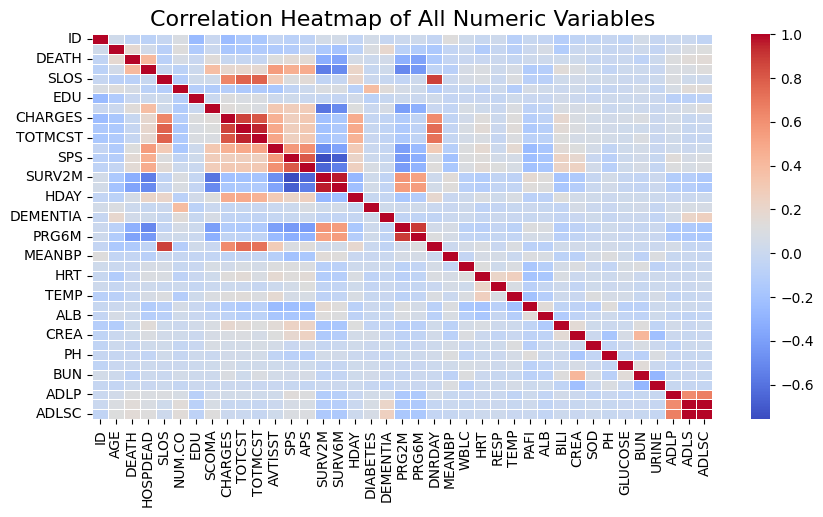

In [550]:
# Compute correlation matrix
corr_matrix = df1.corr(numeric_only=True)        # Correlation matrix for numeric features only

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap of All Numeric Variables", fontsize=16)
plt.show()


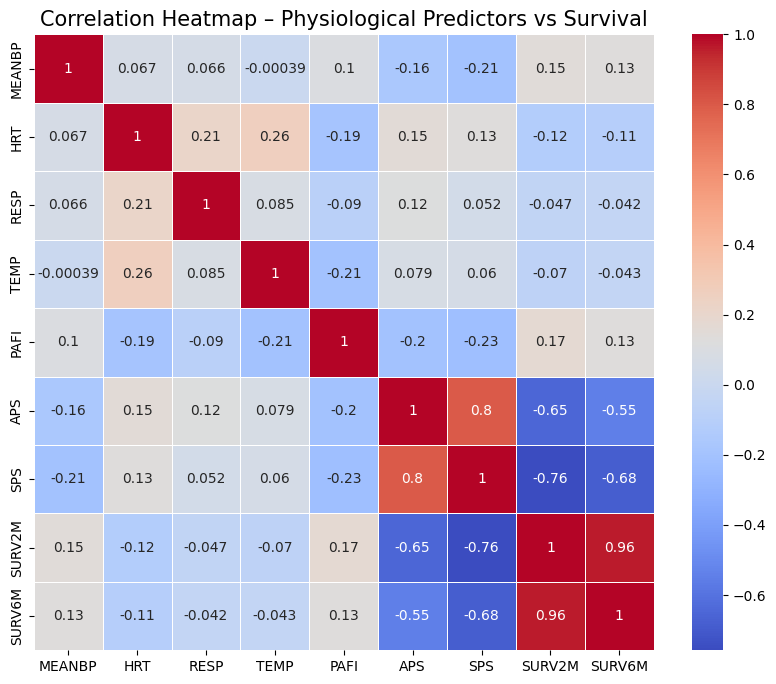

In [537]:
# Select key physiological & survival features
focus_vars = [
    'MEANBP', 'HRT', 'RESP', 'TEMP', 'PAFI', 'APS', 'SPS',
    'SURV2M', 'SURV6M'
]

# Keep only columns that exist in the dataset
focus_df = df1[[col for col in focus_vars if col in df1.columns]]

# Compute and plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(focus_df.corr(), cmap="coolwarm", annot=True, linewidths=0.5)
plt.title("Correlation Heatmap – Physiological Predictors vs Survival", fontsize=15)
plt.show()


Text(0, 0.5, 'Model Survival Estimate')

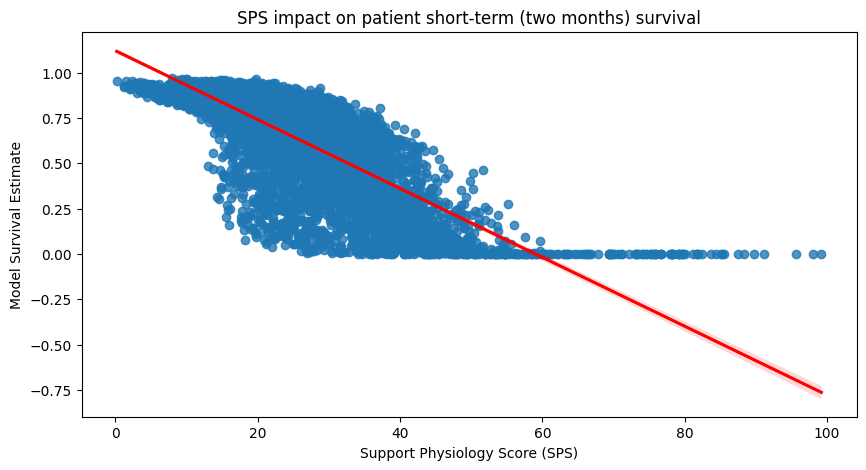

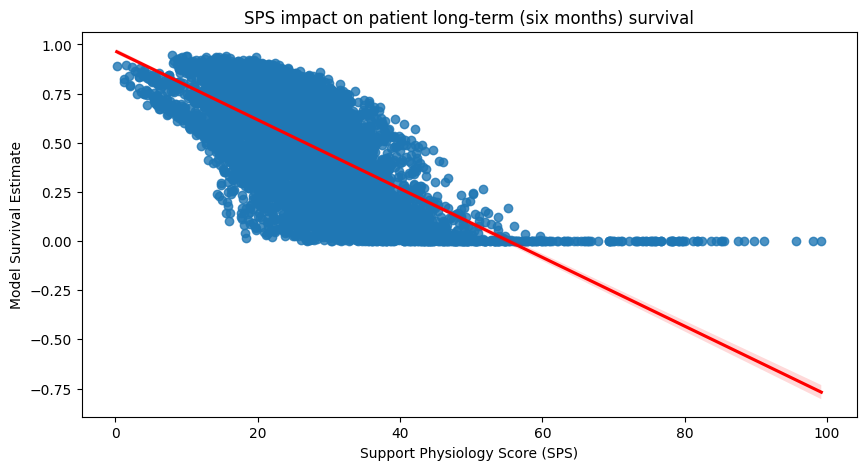

In [549]:
plt.figure(figsize=(10,5))          # SPS survival impact short term (2mnths)
sns.regplot(df1,
               x='SPS',
               y='SURV2M',
           line_kws={'color':'red'})
plt.title('SPS impact on patient short-term (two months) survival')
plt.xlabel('Support Physiology Score (SPS)')
plt.ylabel('Model Survival Estimate')

plt.figure(figsize=(10,5))          # SPS survival impact long term (6mnths)
sns.regplot(df1,
               x='SPS',
               y='SURV6M',
           line_kws={'color':'red'})
plt.title('SPS impact on patient long-term (six months) survival')
plt.xlabel('Support Physiology Score (SPS)')
plt.ylabel('Model Survival Estimate')

Of all the physiological markers in the dataset SPS (physiology score on day 3) shows the highest correlation to short and long term (two and six months) survival chances. The negative correlation indicates that a higher physiological score a patient has, the lower the chances of survival

Determining the correlation between 2 categorical features

In [551]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ calculate Cramers V statistic for categorial-categorial association.
        uses correction from Bergsma and Wicher,
        Journal of the Korean Statistical Society 42 (2013): 323-328
    """
    confusion_matrix = pd.crosstab(x,y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

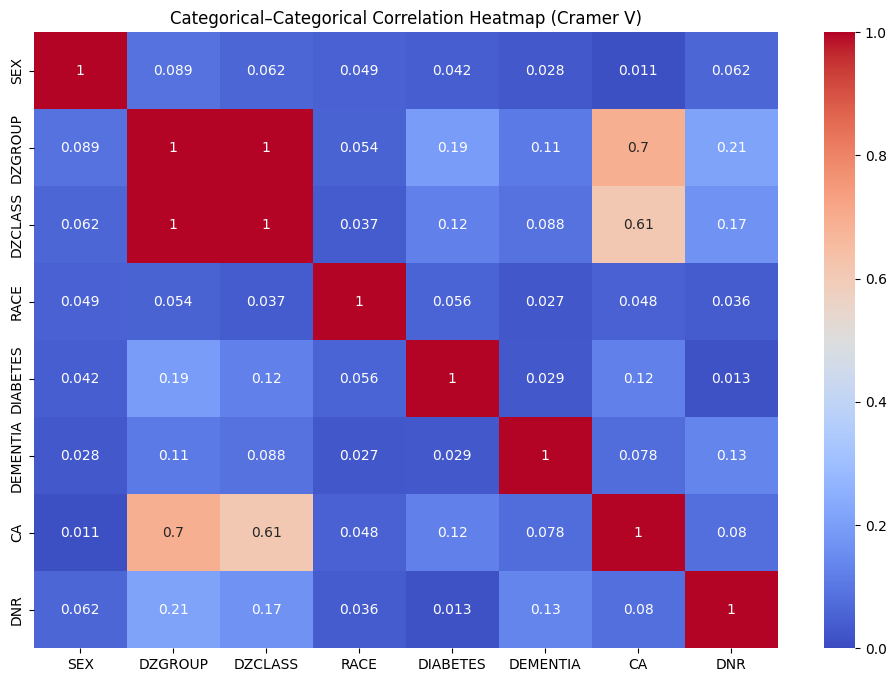

In [555]:
cat_features = ['SEX', 'DZGROUP', 'DZCLASS', 'RACE',         # Locate categorical features
                     'DIABETES', 'DEMENTIA', 'CA', 'DNR']

# Create correlation matrix
cat_corr = pd.DataFrame(index=cat_features, columns=cat_features)

for col1 in cat_features:
    for col2 in cat_features:
        cat_corr.loc[col1, col2] = cramers_v(df1[col1], df1[col2])

cat_corr = cat_corr.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cat_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Categorical–Categorical Correlation Heatmap (Cramer V)")
plt.show()


Strong correlations between cancer and DZGROUP/DZCLASS. If a patient has cancer, he/she is categorized under the Disease class and group (DZGROUP). Holds no value in predicting survival chances of patients

# Findings

1. The average values of the two month predictions skew slightly to the left of the distribution. Indicates a positive skew. Many patients average a prognosis of 0.61 and 0.49 in two and 6 months respectively.
2. Age distribution falls within 50 and 75 years. There are outliers which fall under the 20 year age mark.
3. Age Distribution skews slightly to the right, comparing values of mean and median. Indicates most patient ages are clustered at the lower end of the distribution, although they are closer to the average
4. There are a significantly larger proportion of male patients compared to female patients
5. More patients who arrive in the hospital die there
6. Patients aged 71 years on record died the most whilst 53 year olds died the least. 71 is the ideal age category to make the necessary interventions for
7. Most patients are diagnosed with acute respiratory failure / multi-organ system failure with sepsis, the highest disease group.
8. Many of those patients also come in with Acute Respiratory Failure / Multi-Organ System Failure, which is the highest disease class.
9. Many patients record one to three comorbidities, an average of two comorbidities. Outliers represent patients with more than six comorbidities
10. Patients hospitalized with one, two and three disease/comorbidity value had a stronger chance of dying.
11. Probability of survival reduces with age. Within the considered cluster of patient ages, the chances that a patient will survive with two and six months tends to decrease.
12. About 2700 patients with COPD/CHF/Cirrhosis have a strong chance of surviving within two and six months, even though more patients (above 4000) suffer from ARF/MOSF.
13. In the short and long terms, an increase in the physiological score corresponds to a decrease in the chances of survival. Higher physiological scores indicate worse physiological conditions
14. The APS is a strong predictor of short and long term mortality
15. Physicians assign lower estimated 2-month survival probabilities to Black patients than to White, Hispanic, Asian, or Other patients, even though the overall range of estimates is similarly wide in every racial group.
16. For 6 month estimates, range is still wide and very equal. However, dire black patient predictions disappear. Asians record the lowest median predictions while hispanics receive the highest rates. Provide medical interventions to blacks in the short term and to asians in the long term.
17. The model makes race neutral predictions and the median values are quite uniform across races.
18. Outliers in the 2 month prognosis could refer to individuals with high comorbidity rates
19. Race holds no substantive predictive power. Race disparities observed above could be explained by physician bias or clinically unrelated issues
20. Gender holds no relevance or predictive power in survival rates by model or physicians
21. High and steady predictions are surprisingly observed. This could mean that the number of comorbidities are not sufficient sole markers to predict survival with 2 or 6 months
22. Of all the physiological markers in the dataset SPS (physiology score on day 3) shows the highest correlation to short and long term (two and six months) survival chances. The negative correlation indicates that a higher physiological score a patient has, the lower the chances of survival
23. Strong correlations between cancer and DZGROUP/DZCLASS. If a patient has cancer, he/she is categorized under the Disease class and group (DZGROUP). Holds no value in predicting survival chances of patients

# Summary and Recommendations

1. SPS and APS scores are the strongest prediction of patient survival over short and long terms. There is therefore the need to adopt an APS/SPS threshold to flag patients for early review, before their conditions get worse. This will drastically avoid last-minute interventions, prolonging patient lives.
2. Rely on model estimates and not physician estimates entirely. This helps to reduce bias and enhance the accuracy of estimates.
3. Set up advance care interventions when patients fall within at least two high risk categories (Age, SPS/APS and comorbidities).
4. Contextualize interventions within a low socio-economic patient group.
5. Avoid late decisions making to prevent added suffering and extra costs to patients